In [ ]:
import re
import random
from collections import Counter

import numpy as np
import pandas as pd

import torch
from torch.utils.data import Dataset, DataLoader

In [ ]:
SEED = 42
MAX_LEN = 200
BATCH_SIZE = 32
MIN_FREQ = 2

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

PAD_ID = 0
UNK_ID = 1

random.seed(SEED)
torch.manual_seed(SEED)

#  Data Loading

In [ ]:
df = pd.read_csv("IMDB Dataset.csv")

print(df.shape)
df.head()

(50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n")
print(df.isnull().sum())


Dataset shape: (50000, 2)

Columns: ['review', 'sentiment']

Missing values:

review       0
sentiment    0
dtype: int64


In [ ]:
df.duplicated().sum()


np.int64(418)

# Text Preprocessing


In [ ]:
import re
import html

STOPWORDS = {
    "a", "an", "the", "and", "or", "but", "if", "while", "of", "at", "by",
    "for", "with", "about", "against", "between", "into", "through", "during",
    "before", "after", "above", "below", "to", "from", "up", "down", "in",
    "out", "on", "off", "over", "under", "again", "further", "then", "once",
    "here", "there", "when", "where", "why", "how", "all", "any", "both",
    "each", "few", "more", "most", "other", "some", "such", "than", "too",
    "very", "can", "will", "just", "should", "now", "this", "that", "these",
    "those", "is", "am", "are", "was", "were", "be", "been", "being",
    "do", "does", "did", "have", "has", "had", "it", "as", "i", "you"
}

CONTRACTIONS = {
    "aren't": "are not",
    "can't":  "can not",
    "couldn't": "could not",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hasn't": "has not",
    "haven't": "have not",
    "he's": "he is",
    "i'm": "i am",
    "isn't": "is not",
    "it's": "it is",
    "she's": "she is",
    "shouldn't": "should not",
    "that's": "that is",
    "there's": "there is",
    "they're": "they are",
    "wasn't": "was not",
    "we're": "we are",
    "weren't": "were not",
    "what's": "what is",
    "who's": "who is",
    "won't": "will not",
    "wouldn't": "would not",
    "you're": "you are"
}

def expand_contractions(text):
    pattern = re.compile(r"\b(" + "|".join(re.escape(k) for k in CONTRACTIONS.keys()) + r")\b")
    return pattern.sub(lambda x: CONTRACTIONS[x.group()], text)

def clean_text(text):
    text = str(text)
    text = html.unescape(text)
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = expand_contractions(text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()


    tokens = [tok for tok in tokens if tok not in STOPWORDS and len(tok) > 1]

    return " ".join(tokens)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df["clean_review"] = df["review"].apply(clean_text)
df["label"] = df["sentiment"].map({"positive": 1, "negative": 0})

df[["review", "clean_review", "sentiment", "label"]].head()


,review,clean_review,sentiment,label
0,One of the other reviewers has mentioned that ...,one reviewers mentioned watching oz episode ll...,positive,1
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...,positive,1
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...,positive,1
3,Basically there's a family where a little boy ...,basically family little boy jake thinks zombie...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...,positive,1


In [ ]:
from collections import Counter

analysis_counter = Counter()

for text in df["clean_review"]:
    analysis_counter.update(text.split())

top_words = analysis_counter.most_common(20)
display(top_words)

[('not', 125676),
 ('movie', 87276),
 ('film', 79148),
 ('he', 58527),
 ('his', 57236),
 ('one', 53205),
 ('they', 45017),
 ('who', 41925),
 ('so', 40584),
 ('like', 39843),
 ('her', 34537),
 ('what', 31978),
 ('good', 29547),
 ('she', 26950),
 ('would', 26465),
 ('no', 25091),
 ('time', 24904),
 ('my', 24726),
 ('even', 24669),
 ('which', 23239)]

# Tokenizer

In [ ]:
def tokenize(text):
    return text.split()

In [ ]:
sample_text = df.loc[0, "clean_review"]
print(sample_text)
print(tokenize(sample_text)[:20])

one reviewers mentioned watching oz episode ll hooked they right exactly what happened me first thing struck me oz its brutality unflinching scenes violence which set right word go trust me not show faint hearted timid show pulls no punches regards drugs sex violence its hardcore classic use word called oz nickname given oswald maximum security state penitentary focuses mainly emerald city experimental section prison cells glass fronts face inwards so privacy not high agenda em city home many aryans muslims gangstas latinos christians italians irish so scuffles death stares dodgy dealings shady agreements never far away would say main appeal show due fact goes shows would not dare forget pretty pictures painted mainstream audiences forget charm forget romance oz not mess around first episode ever saw struck me so nasty surreal could not say ready watched developed taste oz got accustomed high levels graphic violence not violence injustice crooked guards who ll sold nickel inmates who l

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

sentiment
positive    24884
negative    24698
Name: count, dtype: int64


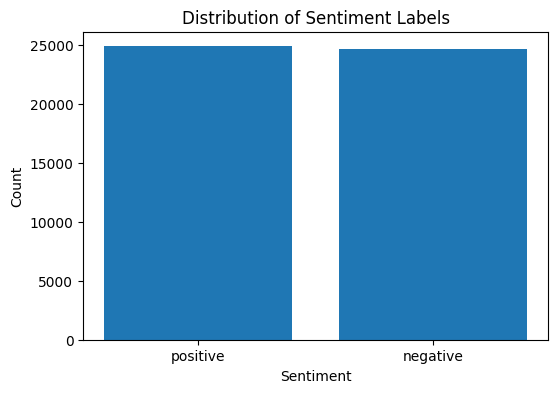

In [ ]:
label_counts = df["sentiment"].value_counts()

print(label_counts)

plt.figure(figsize=(6, 4))
plt.bar(label_counts.index, label_counts.values)
plt.title("Distribution of Sentiment Labels")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [ ]:
df["raw_char_length"] = df["review"].apply(len)
df["raw_word_count"] = df["review"].apply(lambda x: len(str(x).split()))

print(df["raw_char_length"].describe())
print(df["raw_word_count"].describe())

count    49582.000000
mean      1310.568230
std        990.762238
min         32.000000
25%        699.000000
50%        971.000000
75%       1592.000000
max      13704.000000
Name: raw_char_length, dtype: float64
count    49582.000000
mean       231.350167
std        171.542020
min          4.000000
25%        126.000000
50%        173.000000
75%        281.000000
max       2470.000000
Name: raw_word_count, dtype: float64


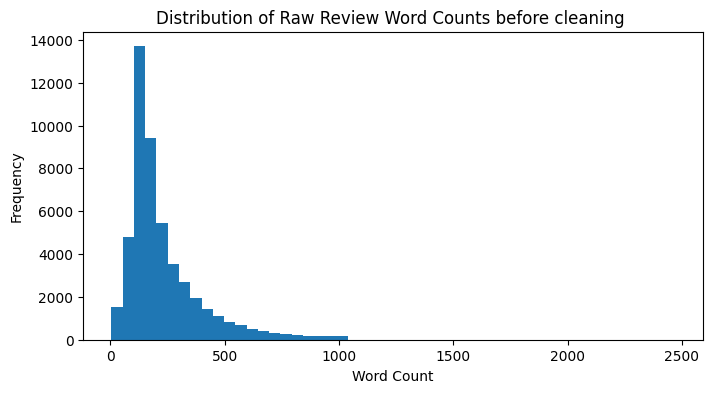

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(df["raw_word_count"], bins=50)
plt.title("Distribution of Raw Review Word Counts before cleaning ")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

In [ ]:
df["clean_word_count"] = df["clean_review"].apply(lambda x: len(tokenize(x)))

print(df["clean_word_count"].describe())

count    49582.000000
mean       133.563128
std        101.673525
min          4.000000
25%         71.000000
50%         99.000000
75%        162.000000
max       1518.000000
Name: clean_word_count, dtype: float64


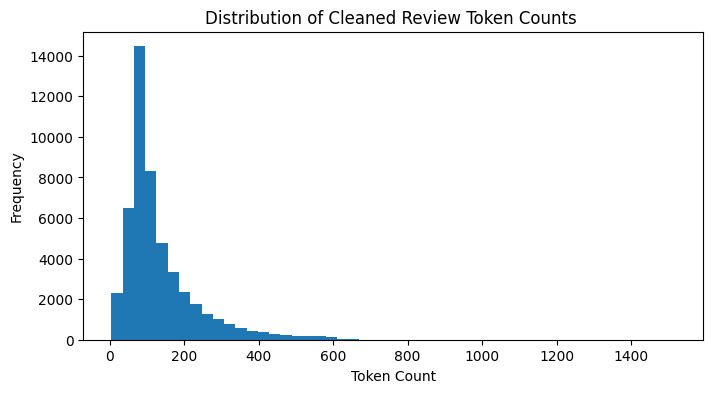

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(df["clean_word_count"], bins=50)
plt.title("Distribution of Cleaned Review Token Counts ")
plt.xlabel("Token Count")
plt.ylabel("Frequency")
plt.show()

In [ ]:
print("Average raw word count:", df["raw_word_count"].mean())
print("Average cleaned token count:", df["clean_word_count"].mean())

Average raw word count: 231.35016739945948
Average cleaned token count: 133.56312774797306


In [ ]:
positive_lengths = df[df["label"] == 1]["clean_word_count"]
negative_lengths = df[df["label"] == 0]["clean_word_count"]

print("Positive average length:", positive_lengths.mean())
print("Negative average length:", negative_lengths.mean())

Positive average length: 135.1169024272625
Negative average length: 131.99765163171108


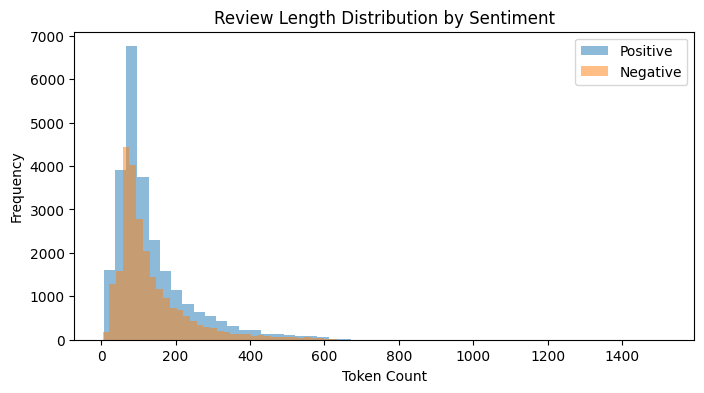

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(positive_lengths, bins=50, alpha=0.5, label="Positive")
plt.hist(negative_lengths, bins=50, alpha=0.5, label="Negative")
plt.title("Review Length Distribution by Sentiment")
plt.xlabel("Token Count")
plt.ylabel("Frequency")
plt.legend()
plt.show()

#  split data


In [ ]:
data = list(zip(df["clean_review"].tolist(), df["label"].tolist()))

random.seed(SEED)
random.shuffle(data)

total_size = len(data)
train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_data = data[:train_size]
val_data = data[train_size:train_size + val_size]
test_data = data[train_size + val_size:]

print("Total:", total_size)
print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

Total: 49582
Train: 34707
Validation: 7437
Test: 7438


# Vocabulary Construction

## Build vocabulary from training corpus only

In [ ]:
def build_vocab(data, min_freq=1):
    counter = Counter()

    for text, _ in data:
        tokens = tokenize(text)
        counter.update(tokens)

    word2idx = {
        PAD_TOKEN: PAD_ID,
        UNK_TOKEN: UNK_ID
    }

    current_idx = 2
    for word, freq in counter.items():
        if freq >= min_freq:
            word2idx[word] = current_idx
            current_idx += 1

    idx2word = {idx: word for word, idx in word2idx.items()}
    return word2idx, idx2word, counter

## Create vocabulary

In [ ]:
word2idx, idx2word, vocab_counter = build_vocab(train_data, min_freq=MIN_FREQ)

print("Vocabulary size:", len(word2idx))
print("First 20 vocab items:")
print(list(word2idx.items())[:20])

Vocabulary size: 54003
First 20 vocab items:
[('<PAD>', 0), ('<UNK>', 1), ('film', 2), ('excellent', 3), ('premise', 4), ('really', 5), ('crying', 6), ('turned', 7), ('hollywood', 8), ('blockbuster', 9), ('recall', 10), ('years', 11), ('since', 12), ('ve', 13), ('seen', 14), ('action', 15), ('starts', 16), ('london', 17), ('omnibus', 18), ('filled', 19)]


In [ ]:
most_common_words = vocab_counter.most_common(20)
print(most_common_words)

[('not', 88453), ('movie', 61310), ('film', 55497), ('he', 40806), ('his', 40294), ('one', 37443), ('they', 31584), ('who', 29480), ('so', 28688), ('like', 27954), ('her', 24201), ('what', 22346), ('good', 20785), ('she', 18873), ('would', 18572), ('no', 17650), ('time', 17613), ('even', 17395), ('my', 17219), ('which', 16434)]


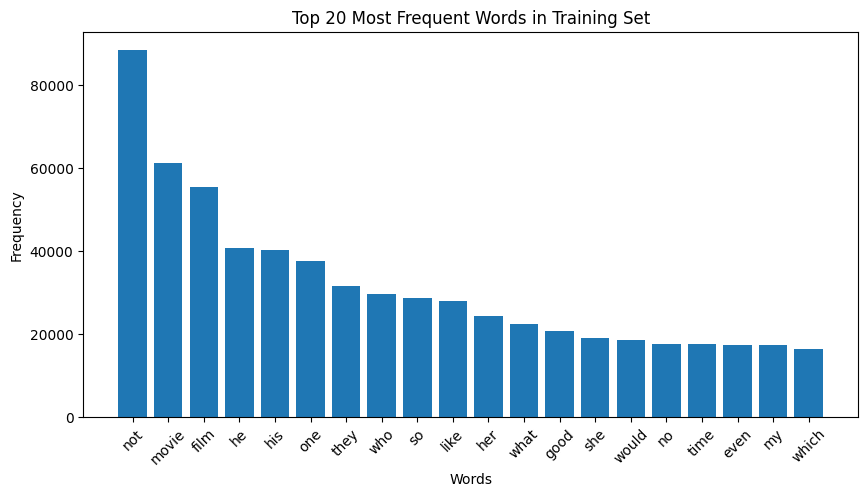

In [ ]:
words = [word for word, freq in most_common_words]
freqs = [freq for word, freq in most_common_words]

plt.figure(figsize=(10, 5))
plt.bar(words, freqs)
plt.title("Top 20 Most Frequent Words in Training Set")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

In [ ]:
import math

def get_log_score(word):
    pos = positive_counter[word] + 1
    neg = negative_counter[word] + 1

    return math.log(pos / neg)

In [ ]:
train_lengths = [len(tokenize(text)) for text, _ in train_data]

print("Min length:", min(train_lengths))
print("Max length:", max(train_lengths))
print("Mean length:", np.mean(train_lengths))
print("Median length:", np.median(train_lengths))
print("95th percentile:", np.percentile(train_lengths, 95))
print("99th percentile:", np.percentile(train_lengths, 99))

Min length: 4
Max length: 1518
Mean length: 134.31509493762064
Median length: 99.0
95th percentile: 350.0
99th percentile: 530.0


In [ ]:
above_max_len = sum(1 for length in train_lengths if length > MAX_LEN)
below_or_equal_max_len = sum(1 for length in train_lengths if length <= MAX_LEN)

print("Sequences longer than MAX_LEN:", above_max_len)
print("Sequences within MAX_LEN:", below_or_equal_max_len)
print("Percentage truncated:", round(above_max_len / len(train_lengths) * 100, 2), "%")

Sequences longer than MAX_LEN: 6155
Sequences within MAX_LEN: 28552
Percentage truncated: 17.73 %


In [ ]:
print("Vocabulary size:", len(word2idx))
print("Special tokens:")
print(PAD_TOKEN, "->", word2idx[PAD_TOKEN])
print(UNK_TOKEN, "->", word2idx[UNK_TOKEN])

Vocabulary size: 54003
Special tokens:
<PAD> -> 0
<UNK> -> 1


# Convert tokens to indices

In [ ]:
def text_to_ids(text, vocab):
    tokens = tokenize(text)
    return [vocab.get(token, UNK_ID) for token in tokens]

# Padding

In [ ]:
def pad_or_truncate(sequence, max_len=200, pad_id=PAD_ID):
    if len(sequence) > max_len:
        return sequence[:max_len]
    else:
        return sequence + [pad_id] * (max_len - len(sequence))

In [ ]:
total_token_count = sum(vocab_counter.values())

sorted_freqs = sorted(vocab_counter.values(), reverse=True)

coverage_100 = sum(sorted_freqs[:100]) / total_token_count
coverage_500 = sum(sorted_freqs[:500]) / total_token_count
coverage_1000 = sum(sorted_freqs[:1000]) / total_token_count

print("Top 100 token coverage:", round(coverage_100 * 100, 2), "%")
print("Top 500 token coverage:", round(coverage_500 * 100, 2), "%")
print("Top 1000 token coverage:", round(coverage_1000 * 100, 2), "%")

Top 100 token coverage: 29.13 %
Top 500 token coverage: 51.04 %
Top 1000 token coverage: 61.8 %


In [ ]:
def calculate_unk_ratio(data, vocab):
    total_tokens = 0
    unk_tokens = 0

    for text, _ in data:
        token_ids = text_to_ids(text, vocab)
        total_tokens += len(token_ids)
        unk_tokens += sum(1 for tid in token_ids if tid == UNK_ID)

    return unk_tokens / total_tokens if total_tokens > 0 else 0

train_unk_ratio = calculate_unk_ratio(train_data, word2idx)
val_unk_ratio = calculate_unk_ratio(val_data, word2idx)
test_unk_ratio = calculate_unk_ratio(test_data, word2idx)

print("Train UNK ratio:", round(train_unk_ratio, 4))
print("Validation UNK ratio:", round(val_unk_ratio, 4))
print("Test UNK ratio:", round(test_unk_ratio, 4))

Train UNK ratio: 0.0069
Validation UNK ratio: 0.0128
Test UNK ratio: 0.0126


In [ ]:
def count_pad_tokens_in_dataset(data, vocab, max_len):
    total_pad = 0
    total_tokens_after_padding = 0

    for text, _ in data:
        ids = text_to_ids(text, vocab)
        padded = pad_or_truncate(ids, max_len)
        total_pad += padded.count(PAD_ID)
        total_tokens_after_padding += len(padded)

    return total_pad, total_tokens_after_padding

train_pad, train_total = count_pad_tokens_in_dataset(train_data, word2idx, MAX_LEN)

print("Total PAD tokens in training set:", train_pad)
print("PAD ratio in training set:", round(train_pad / train_total, 4))

Total PAD tokens in training set: 2986384
PAD ratio in training set: 0.4302


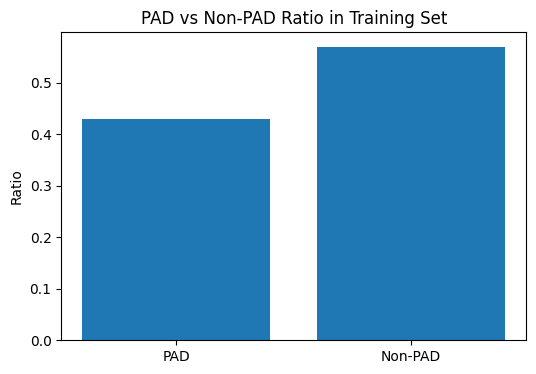

In [ ]:
pad_ratio = train_pad / train_total
non_pad_ratio = 1 - pad_ratio

plt.figure(figsize=(6, 4))
plt.bar(["PAD", "Non-PAD"], [pad_ratio, non_pad_ratio])
plt.title("PAD vs Non-PAD Ratio in Training Set")
plt.ylabel("Ratio")
plt.show()

# encoding

In [ ]:
def encode_text(text, vocab, max_len=200):
    token_ids = text_to_ids(text, vocab)
    token_ids = pad_or_truncate(token_ids, max_len=max_len, pad_id=PAD_ID)
    return token_ids

In [ ]:
data_encoded = encode_text(train_data[0][0], word2idx, MAX_LEN)
print("Encoded length:", len(data_encoded))
print(data_encoded[:30])

Encoded length: 200
[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 2, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 2, 27, 28, 29]


# Attention Architect
## Scaled Dot-Product Attention & Multi-Head Attention from Scratch
**Paper:** *Attention Is All You Need*

# Data Loader

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from torch.utils.data import Dataset, DataLoader

# ── IMDbDataset ───────────────────────────────────────────────────────────────
class IMDbDataset(Dataset):

    def __init__(self, data, vocab, max_len=MAX_LEN):
        self.data    = data
        self.vocab   = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text, label = self.data[idx]
        token_ids   = encode_text(text, self.vocab, self.max_len)  # list[int]
        ids_tensor  = torch.tensor(token_ids, dtype=torch.long)
        mask        = (ids_tensor != PAD_ID).long()                # (seq_len,)
        return ids_tensor, torch.tensor(label, dtype=torch.long), mask


# ── Build loaders ─────────────────────────────────────────────────────────────
train_dataset = IMDbDataset(train_data, word2idx, MAX_LEN)
val_dataset   = IMDbDataset(val_data,   word2idx, MAX_LEN)
test_dataset  = IMDbDataset(test_data,  word2idx, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# ── Quick verification ────────────────────────────────────────────────────────
ids, labels, masks = next(iter(train_loader))

print("── DataLoader verification ──────────────────────────")
print(f"  ids shape    : {tuple(ids.shape)}    (batch, seq_len)")
print(f"  labels shape : {tuple(labels.shape)}")
print(f"  mask shape   : {tuple(masks.shape)}    (batch, seq_len)")
print(f"  PAD positions: {(ids[0] == PAD_ID).sum().item()} / {MAX_LEN} in first sample")
print(f"  Label sample : {labels[:8].tolist()}")
print()


── DataLoader verification ──────────────────────────
  ids shape    : (32, 200)    (batch, seq_len)
  labels shape : (32,)
  mask shape   : (32, 200)    (batch, seq_len)
  PAD positions: 72 / 200 in first sample
  Label sample : [0, 1, 1, 0, 1, 1, 1, 0]



# Scaled Dot-Product Attention

In [ ]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, Q, K, V, mask=None):
        # Step 1: d_k from K's last dim
        d_k = K.size(-1)

        # Step 2: Q · Kᵀ  →  (batch, seq_q, seq_kv)
        scores = torch.bmm(Q, K.transpose(-2, -1))

        # Step 3: scale  ÷ √d_k
        scores = scores / math.sqrt(d_k)

        # Step 4: mask padding positions → -inf so softmax gives 0
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))

        # Step 5: softmax over key axis
        attn_weights = F.softmax(scores, dim=-1)

        # Step 6: dropout
        attn_weights = self.dropout(attn_weights)

        # Step 7: weighted sum over V  →  (batch, seq_q, d_v)
        output = torch.bmm(attn_weights, V)

        return output, attn_weights


# ── Dimension verification ────────────────────────────────────────────────────
_batch, _seq, _dk, _dv = 2, MAX_LEN, 32, 32
_Q = torch.randn(_batch, _seq, _dk)
_K = torch.randn(_batch, _seq, _dk)
_V = torch.randn(_batch, _seq, _dv)

_sdpa = ScaledDotProductAttention(dropout=0.0)
_sdpa.eval()
_out, _w = _sdpa(_Q, _K, _V)

assert _out.shape == (_batch, _seq, _dv),      f"FAIL output: {_out.shape}"
assert _w.shape   == (_batch, _seq, _seq),     f"FAIL weights: {_w.shape}"
assert torch.allclose(_w.sum(-1), torch.ones(_batch, _seq), atol=1e-5)

print("── ScaledDotProductAttention ────────────────────────")
print(f"  Q/K shape    : {tuple(_Q.shape)}")
print(f"  V shape      : {tuple(_V.shape)}")
print(f"  output shape : {tuple(_out.shape)}")
print(f"  weights shape: {tuple(_w.shape)}")

del _batch, _seq, _dk, _dv, _Q, _K, _V, _sdpa, _out, _w


── ScaledDotProductAttention ────────────────────────
  Q/K shape    : (2, 200, 32)
  V shape      : (2, 200, 32)
  output shape : (2, 200, 32)
  weights shape: (2, 200, 200)


# Multi Head Attention

In [ ]:
class MultiHeadAttention(nn.Module):

    def __init__(self, d_model: int, h: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % h == 0, f"d_model ({d_model}) must be divisible by h ({h})"

        self.d_model = d_model
        self.h       = h
        self.d_k     = d_model // h
        self.d_v     = d_model // h
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
        self.attention = ScaledDotProductAttention(dropout=dropout)

        for lin in [self.W_q, self.W_k, self.W_v, self.W_o]:
            nn.init.xavier_uniform_(lin.weight)

    def _split_heads(self, x):
        B, S, _ = x.size()
        x = x.view(B, S, self.h, self.d_k).transpose(1, 2)
        return x.contiguous().view(B * self.h, S, self.d_k)

    def _merge_heads(self, x, B):
        x = x.view(B, self.h, -1, self.d_v).transpose(1, 2).contiguous()
        return x.view(B, -1, self.h * self.d_v)

    def forward(self, Q, K, V, mask=None):
        B = Q.size(0)

        Q_p = self.W_q(Q)
        K_p = self.W_k(K)
        V_p = self.W_v(V)

        Q_h = self._split_heads(Q_p)
        K_h = self._split_heads(K_p)
        V_h = self._split_heads(V_p)

        head_mask = None
        if mask is not None:
            if mask.dim() == 2:
                mask = mask.unsqueeze(1).unsqueeze(2)
            head_mask = mask.expand(B, self.h, mask.size(-2), mask.size(-1))
            head_mask = head_mask.contiguous().view(
                B * self.h, mask.size(-2), mask.size(-1))

        attn_out, attn_weights = self.attention(Q_h, K_h, V_h, head_mask)

        concat = self._merge_heads(attn_out, B)

        output = self.W_o(concat)

        attn_weights = attn_weights.view(B, self.h, -1, K.size(1))
        return output, attn_weights


D_MODEL = 128
H       = 4

_ids, _labels, _masks = next(iter(train_loader))
_B, _S = _ids.shape

_dummy_embed = nn.Embedding(len(word2idx), D_MODEL, padding_idx=PAD_ID)
_x = _dummy_embed(_ids)

_mha = MultiHeadAttention(d_model=D_MODEL, h=H, dropout=0.0)
_mha.eval()

_out, _w = _mha(_x, _x, _x, mask=_masks)

assert _out.shape == (_B, _S, D_MODEL),             f"FAIL output: {_out.shape}"
assert _w.shape   == (_B, H, _S, _S),               f"FAIL weights: {_w.shape}"
assert torch.isfinite(_out).all(),                   "FAIL: NaN in output"

_loss = _out.sum()
_loss.backward()
for name, p in _mha.named_parameters():
    assert p.grad is not None, f"No grad on {name}"

total_params = sum(p.numel() for p in _mha.parameters())

print("── MultiHeadAttention ───────────────────────────────")
print(f"  Config        : d_model={D_MODEL}, h={H}, d_k={D_MODEL//H}")
print(f"  Real batch    : ids={tuple(_ids.shape)} → embed={tuple(_x.shape)}")
print(f"  Output shape  : {tuple(_out.shape)}")
print(f"  Weights shape : {tuple(_w.shape)}  (batch, h, seq, seq)")
print(f"  Parameters    : {total_params:,}")


del _ids, _labels, _masks, _dummy_embed, _x, _mha, _out, _w, _loss


── MultiHeadAttention ───────────────────────────────
  Config        : d_model=128, h=4, d_k=32
  Real batch    : ids=(32, 200) → embed=(32, 200, 128)
  Output shape  : (32, 200, 128)
  Weights shape : (32, 4, 200, 200)  (batch, h, seq, seq)
  Parameters    : 65,536


In [ ]:
import torch
import torch.nn as nn
import math
import torch.optim as optim
from tqdm import tqdm

In [ ]:
def create_padding_mask(token_ids, pad_idx=0):
    return (token_ids != pad_idx).long()

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_len=200, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_seq_len, d_model)
        position = torch.arange(0, max_seq_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0) # (1, max_seq_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

In [ ]:
class FeedForwardNetwork(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout)
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.linear2(self.dropout(self.relu(self.linear1(x))))

In [ ]:
class LayerNormalization(nn.Module):
    def __init__(self, d_model, epsilon=1e-6):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(d_model))
        self.beta = nn.Parameter(torch.zeros(d_model))
        self.epsilon = epsilon

    def forward(self, x):
        mean = x.mean(-1, keepdim=True)
        std = x.std(-1, keepdim=True)
        return self.gamma * (x - mean) / (std + self.epsilon) + self.beta

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadAttention(d_model=d_model, h=num_heads, dropout=dropout)
        self.ffn = FeedForwardNetwork(d_model=d_model, d_ff=d_ff, dropout=dropout)
        self.norm1 = LayerNormalization(d_model)
        self.norm2 = LayerNormalization(d_model)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x, mask=None):
        # Multi-Head Attention + Residual
        attn_output, _ = self.attention(x, x, x, mask=mask)
        x = self.norm1(x + self.dropout(attn_output))

        # FFN + Residual
        ffn_output = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_output))
        return x

In [ ]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=128, num_heads=4, d_ff=512, num_blocks=2, max_seq_len=200, dropout=0.1, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos_encoding = PositionalEncoding(d_model, max_seq_len, dropout)

        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_blocks)
        ])

        self.classifier = nn.Linear(d_model, 1) # مخرج واحد لتصنيف ثنائي (Sentiment)

    def forward(self, token_ids, mask=None):
        x = self.embedding(token_ids)
        x = self.pos_encoding(x)

        # تمرير القناع (mask) عبر طبقات الـ Attention
        # تحويل القناع ليناسب أبعاد الـ Attention (batch, 1, 1, seq_len)
        if mask is not None:
            mask = mask.unsqueeze(1).unsqueeze(2)

        for block in self.blocks:
            x = block(x, mask=mask)

        # Global Average Pooling عبر طول المتوالية
        x = x.mean(dim=1)
        logits = self.classifier(x)
        return logits.squeeze(-1)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
model = TransformerClassifier(
    vocab_size = len(word2idx),
    d_model = 128,
    num_heads = 4,
    d_ff = 512,
    num_blocks = 2,
    max_seq_len = MAX_LEN,
    dropout = 0.1,
    pad_idx=word2idx.get('<PAD>', 0)
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for ids, labels, _ in tqdm(loader):
        ids, labels = ids.to(device), labels.to(device).float()
        optimizer.zero_grad()
        outputs = model(ids)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

# Training & Metrics

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import math
import matplotlib.pyplot as plt
from tqdm import tqdm
import copy

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")


device: cuda


**clip gradients**

In [ ]:
def clip_gradients(model, max_norm=1.0):
    # بنجمع كل الـ gradients من كل parameters
    params = [p for p in model.parameters() if p.grad is not None]

    # بنحسب الـ global L2 norm
    total_norm = 0.0
    for p in params:
        total_norm += p.grad.data.norm(2).item() ** 2
    total_norm = math.sqrt(total_norm)

    # لو الـ norm عدى الـ max بنضرب كل gradient في معامل تصغير
    clip_coef = max_norm / (total_norm + 1e-8)
    if clip_coef < 1.0:
        for p in params:
            p.grad.data.mul_(clip_coef)

    return total_norm

**Manual Metrics**

In [ ]:
def compute_metrics(preds, labels):
    preds  = np.array(preds)
    labels = np.array(labels)

    TP = int(((preds == 1) & (labels == 1)).sum())
    FP = int(((preds == 1) & (labels == 0)).sum())
    FN = int(((preds == 0) & (labels == 1)).sum())
    TN = int(((preds == 0) & (labels == 0)).sum())

    accuracy  = (TP + TN) / (TP + FP + FN + TN + 1e-8)
    precision = TP / (TP + FP + 1e-8)
    recall    = TP / (TP + FN + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)

    return {"accuracy": accuracy, "precision": precision,
            "recall": recall, "f1": f1}

 **Training Loop**

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
                num_epochs=20, max_grad_norm=1.0, patience=4):

    history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}

    best_val_loss = float("inf")
    best_weights  = None
    no_improve    = 0

    for epoch in range(1, num_epochs + 1):

        # training
        model.train()
        train_loss = 0.0

        for ids, labels, masks in tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs}", leave=False):
            ids    = ids.to(device)
            labels = labels.to(device).float()
            masks  = masks.to(device)

            optimizer.zero_grad()
            logits = model(ids, mask=masks)
            loss   = criterion(logits, labels)
            loss.backward()

            clip_gradients(model, max_norm=max_grad_norm)

            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)

        # validation
        model.eval()
        val_loss   = 0.0
        all_preds  = []
        all_labels = []

        with torch.no_grad():
            for ids, labels, masks in val_loader:
                ids    = ids.to(device)
                labels = labels.to(device).float()
                masks  = masks.to(device)

                logits = model(ids, mask=masks)
                val_loss += criterion(logits, labels).item()

                preds = (torch.sigmoid(logits) >= 0.5).long()
                all_preds.extend(preds.cpu().numpy().tolist())
                all_labels.extend(labels.cpu().long().numpy().tolist())

        val_loss /= len(val_loader)
        metrics   = compute_metrics(all_preds, all_labels)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(metrics["accuracy"])
        history["val_f1"].append(metrics["f1"])

        print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | Acc: {metrics['accuracy']:.4f} | F1: {metrics['f1']:.4f}")

        # early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights  = copy.deepcopy(model.state_dict())
            no_improve    = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    return history, best_weights

**Text Evaluation**

In [ ]:
def evaluate_on_test(model, test_loader, criterion):
    model.eval()
    test_loss  = 0.0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for ids, labels, masks in test_loader:
            ids    = ids.to(device)
            labels = labels.to(device).float()
            masks  = masks.to(device)

            logits = model(ids, mask=masks)
            test_loss += criterion(logits, labels).item()

            preds = (torch.sigmoid(logits) >= 0.5).long()
            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().long().numpy().tolist())

    test_loss /= len(test_loader)
    metrics    = compute_metrics(all_preds, all_labels)

    print("\n── Test Results ──────────────────────")
    print(f"  Loss      : {test_loss:.4f}")
    print(f"  Accuracy  : {metrics['accuracy']:.4f}")
    print(f"  Precision : {metrics['precision']:.4f}")
    print(f"  Recall    : {metrics['recall']:.4f}")
    print(f"  F1        : {metrics['f1']:.4f}")

    return test_loss, metrics



In [ ]:
def plot_history(history, title="Training"):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontweight="bold")

    axes[0].plot(epochs, history["train_loss"], "b-o", label="Train Loss", markersize=4)
    axes[0].plot(epochs, history["val_loss"],   "r-o", label="Val Loss",   markersize=4)
    axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, history["val_acc"], "g-s", label="Val Accuracy", markersize=4)
    axes[1].plot(epochs, history["val_f1"],  "m-^", label="Val F1",       markersize=4)
    axes[1].set_title("Validation Metrics"); axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

Epoch 01 | Train Loss: 0.5403 | Val Loss: 0.4452 | Acc: 0.7966 | F1: 0.8152


Epoch 02 | Train Loss: 0.4238 | Val Loss: 0.3879 | Acc: 0.8263 | F1: 0.8374


Epoch 03 | Train Loss: 0.3803 | Val Loss: 0.3873 | Acc: 0.8286 | F1: 0.8244


Epoch 04 | Train Loss: 0.3582 | Val Loss: 0.3576 | Acc: 0.8482 | F1: 0.8547


Epoch 05 | Train Loss: 0.3373 | Val Loss: 0.3694 | Acc: 0.8505 | F1: 0.8625


...

Epoch 09 | Train Loss: 0.2685 | Val Loss: 0.3306 | Acc: 0.8639 | F1: 0.8685


Epoch 10 | Train Loss: 0.2556 | Val Loss: 0.3533 | Acc: 0.8623 | F1: 0.8740


Epoch 11 | Train Loss: 0.2445 | Val Loss: 0.3488 | Acc: 0.8607 | F1: 0.8614


Epoch 12 | Train Loss: 0.2297 | Val Loss: 0.3655 | Acc: 0.8556 | F1: 0.8510


Epoch 13 | Train Loss: 0.2184 | Val Loss: 0.3742 | Acc: 0.8684 | F1: 0.8781
Early stopping at epoch 13

── Test Results ──────────────────────
  Loss      : 0.3530
  Accuracy  : 0.8553
  Precision : 0.8542
  Recall    : 0.8560
  F1        : 0.8551


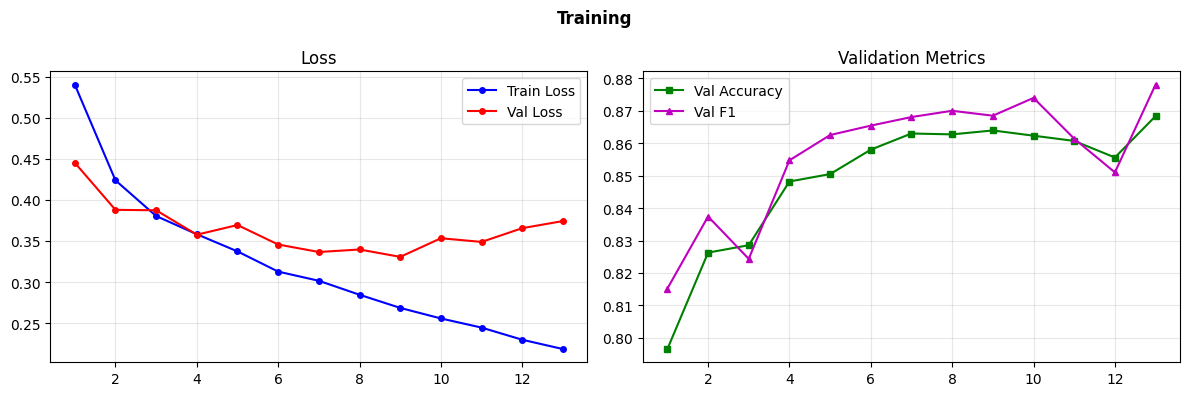

In [ ]:
model = TransformerClassifier(
    vocab_size  = len(word2idx),
    d_model     = 128,
    num_heads   = 4,
    d_ff        = 512,
    num_blocks  = 2,
    max_seq_len = MAX_LEN,
    dropout     = 0.1,
    pad_idx     = word2idx.get("<PAD>", 0)
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

history, best_weights = train_model(
    model, train_loader, val_loader,
    criterion, optimizer,
    num_epochs=20, max_grad_norm=1.0, patience=4
)

model.load_state_dict(best_weights)
test_loss, test_metrics = evaluate_on_test(model, test_loader, criterion)

plot_history(history)